In [1]:
from kickercontrol.main import SetKicker
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)
import numpy as np

from kickercontrol.main import MacroScan, Scan


In [2]:
from kickercontrol.timing import get_region_bounds
get_region_bounds('2')

(831.0153846153846, 988.3076923076924)

[32768. 32768. 32768. ... 32767. 32767. 32767.]
Unable to Restore Initial Kicker Conditions


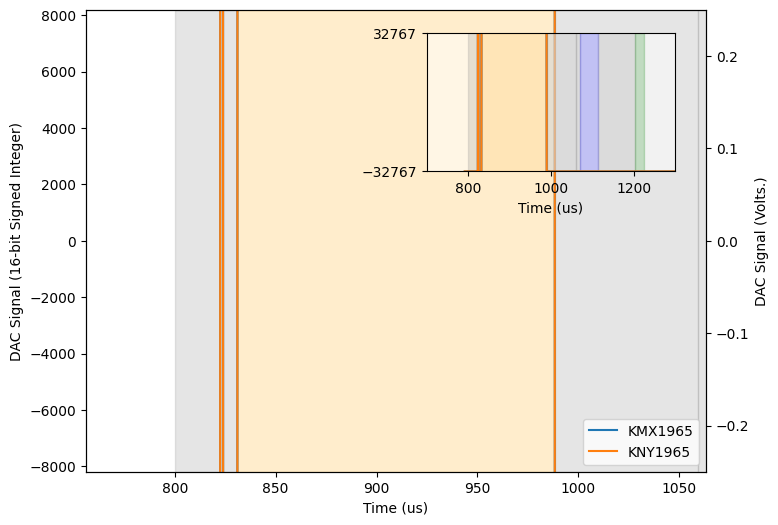

In [24]:

scan_output = MacroScan([KMX1965,KNY1965],
            scan_vectors = [np.linspace(0.8,1,15),np.linspace(0.8,1,15)],
            all_messages=False,
            display = True,
            beamline = '2',
			wait_time=5,
			write_dac = True,
			relative_scan = False
            )

In [7]:



SetKicker(KMX1938,
		  value = -1,
		  beamline = '2',
		  write_dac=True,
		  )

initial kicker conditions saved
# Scan Points: 1


0it [00:00, ?it/s]

Writing signal to kicker XFEL.DIAG/SIS8300DMA/DI1950TL.4/DAC_CH0.TD...
Succesful Write


In [24]:
from kickercontrol.timing import get_region_bounds
get_region_bounds('2')

(831.0153846153846, 988.3076923076924)

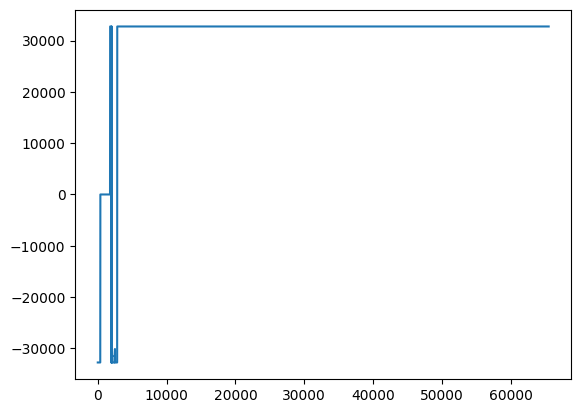

In [8]:
from kickercontrol.signal import DACSignalGenerator
dac_generator = DACSignalGenerator(KL2005(), beamline = None )

from matplotlib import pyplot as plt
plt.plot(K.read_dac()[:,1])

## Single Kicker Scans

[-32768. -32768. -32768. ... -32768. -32768. -32768.]
Unable to Restore Initial Kicker Conditions


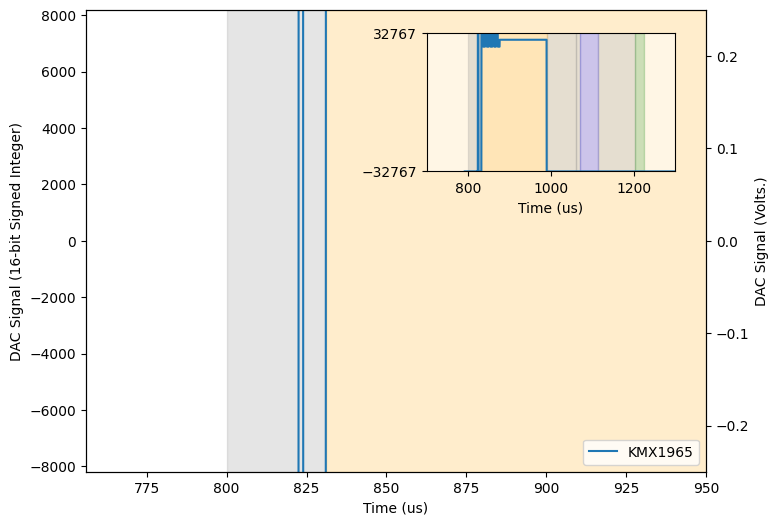

In [18]:
import numpy as np

from kickercontrol.main import SquareScan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')
tf = 875
SquareScan(kicker_device = KMX1965,
		   end_time=tf,
           scan_vector = np.linspace(0,5,25)/((tf-ti)),
           scan_variable="V4",
           amplitude = 0.1,
		   offset = 0.9,
           duty = 0.5,
           n_frequency=2,
           wait_time = 5,
		   write_dac=True,
		   relative_scan=False)
           

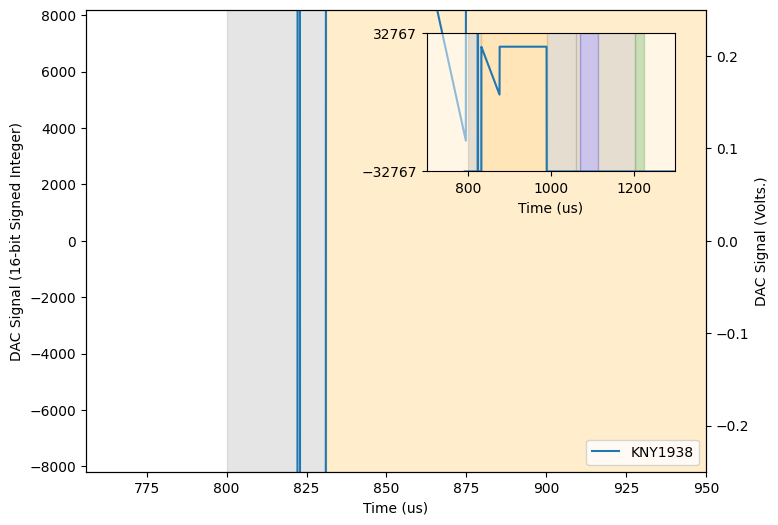

13it [00:58,  4.49s/it]


KeyboardInterrupt: 

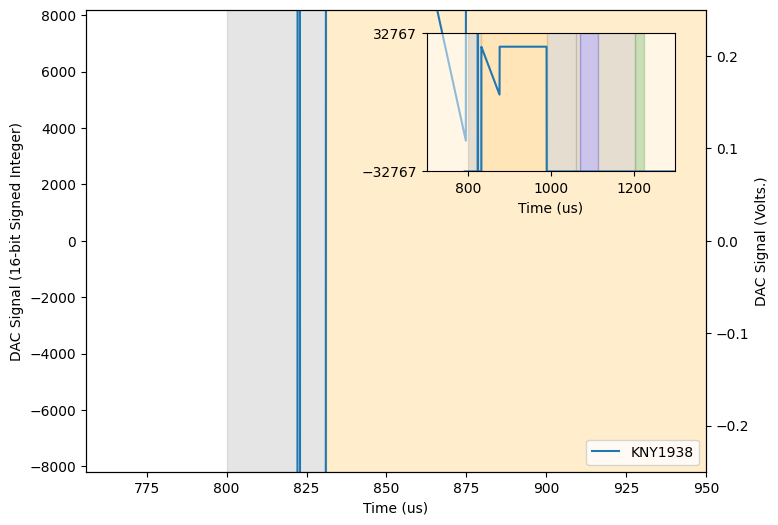

In [22]:
import numpy as np

from kickercontrol.main import RampScan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')
tf = 875

RampScan(kicker_device = KNY1938,
		   end_time=tf,
		   scan_variable="V4",
           scan_vector = np.linspace(0,0.2,25),
		   start_value=0.8,
		   offset=0.8,
		   end_value=0.8,
           wait_time = 5,
		   write_dac=True,
		   relative_scan=False)

RampScan(kicker_device = KNY1938,
		   end_time=875,
		   scan_variable="V1",
           scan_vector = np.linspace(875, 845,25),
		   start_value=0.8,
		   offset=0.8,
		   end_value=1,
           wait_time = 5,
		   write_dac=True,
		   relative_scan=False)
           
           

[-32768. -32768. -32768. ... -32768. -32768. -32768.]
Unable to Restore Initial Kicker Conditions


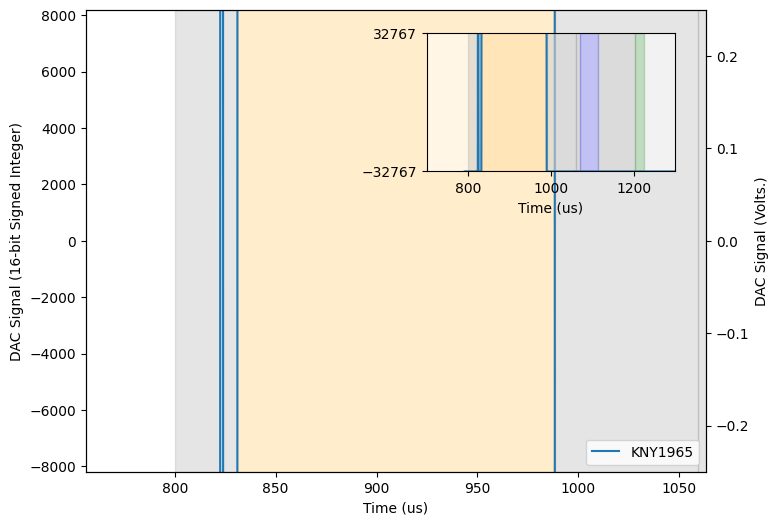

In [8]:
import numpy as np

from kickercontrol.main import MacroScan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

MacroScan(kicker_devices=[KNY1965],
          scan_vectors=[np.linspace(-1,1,125)],
                        write_dac=True,
                        display = True,                     
                        beamline = '2',
                        wait_time=5)


[-32768. -32768. -32768. ... -32768. -32768. -32768.]
Unable to Restore Initial Kicker Conditions


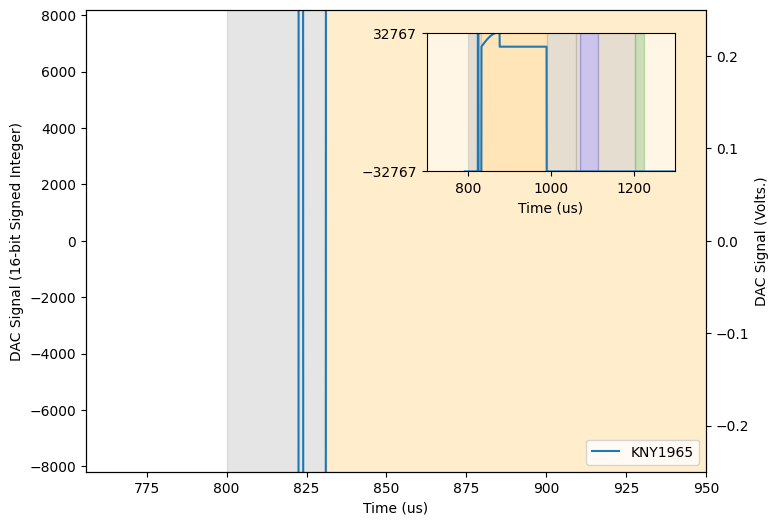

In [14]:
import numpy as np

from kickercontrol.main import SinScan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')
tf = 875

SinScan(kicker_device = KNY1965,
           scan_vector = np.linspace(0,25,25)/((tf-ti)),
           scan_variable="V4",
		   start_time = ti,
		   end_time = tf,
		   
           amplitude = 0.2,
		   offset=0.8,

           periods = np.linspace(0,25,25)/((tf-ti)),
           write_dac = True,
           wait_time = 5,
           display=True,
		   relative_scan=False)

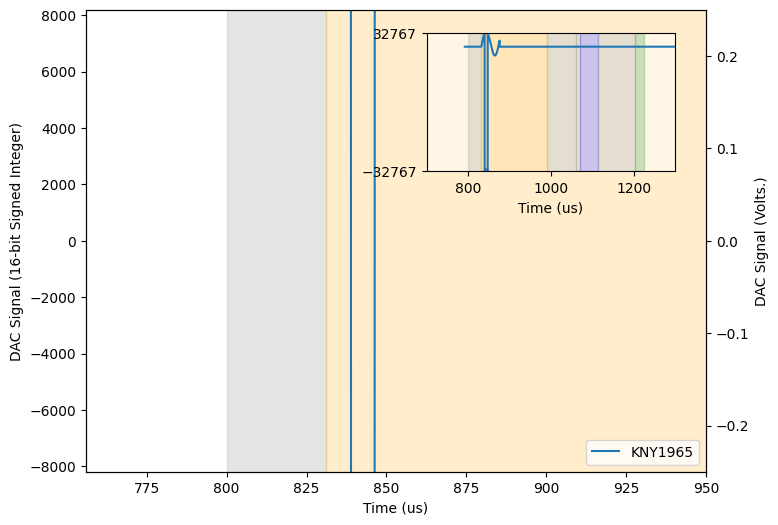

21it [05:01, 14.34s/it]


KeyboardInterrupt: 

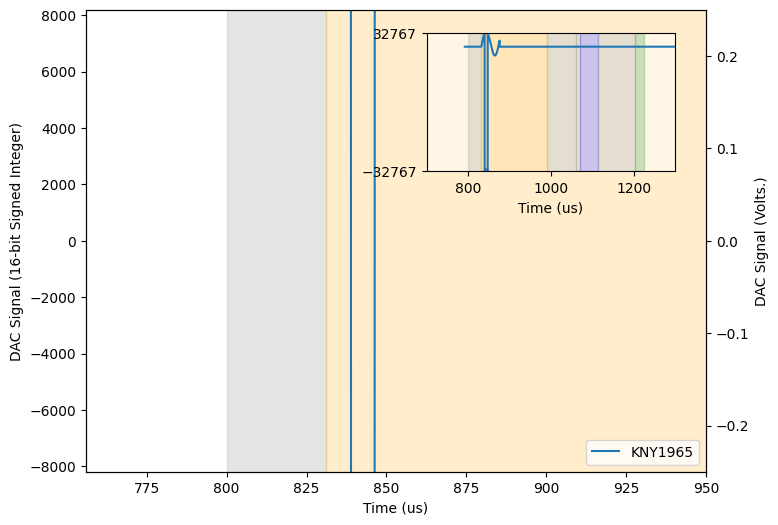

In [15]:
import numpy as np

from kickercontrol.main import Scan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')
tf = 875
# V3: Amplitude of the first sine wave (base amplitude)
# V4: Frequency of the first sine wave (base frequency)
# V5: Fractional amplitude of the second sine wave (relative to V3)
# V6: Fractional frequency of the second sine wave (relative to V4)
# V7: Relative phase shift for the second sine wave (in radians)

Scan(kicker_devices = [KNY1965],
                oscillators=['custom'],
                oscillator_variables=[{"V0": ti, "V1":tf,
                                       "V2": 0.8,"V3": 0.2,
                                       "V4": 1/(tf-ti),
                                       "V5":1/2, "V6": 2, "V7": 0}],
                expression = "V2 + V3 * np.sin(2 * np.pi * V4 * (t - V0)) \
      + (V5 * V3) * np.sin(2 * np.pi * (V6 * V4) * (t - V0) + V7)\
",
                  scan_variables=["V6"],
                  scan_vectors=[np.linspace(1/2,1/8,25)],
                  display = True, wait_time=15,
				  write_dac=True)

[32768. 32768. 32768. ... 32767. 32767. 32767.]
Unable to Restore Initial Kicker Conditions


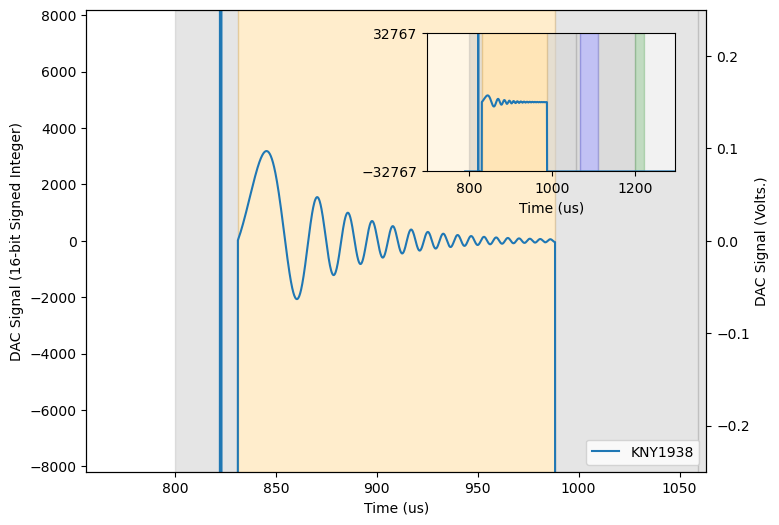

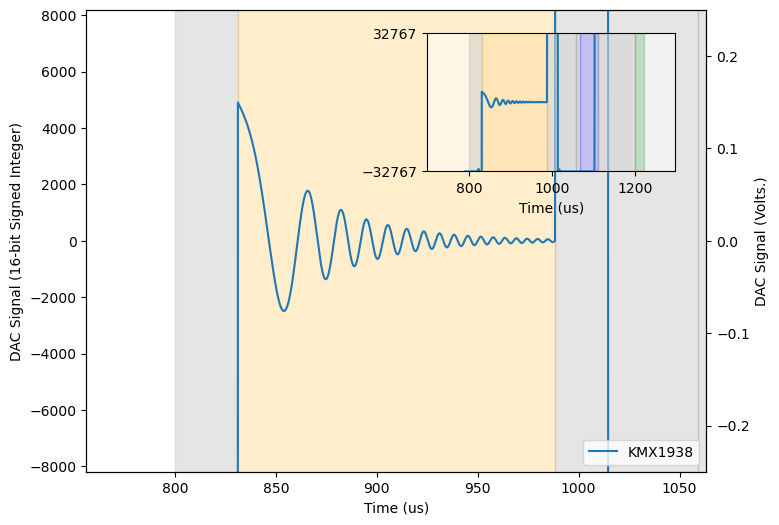

(831.0153846153846, 988.3076923076924)

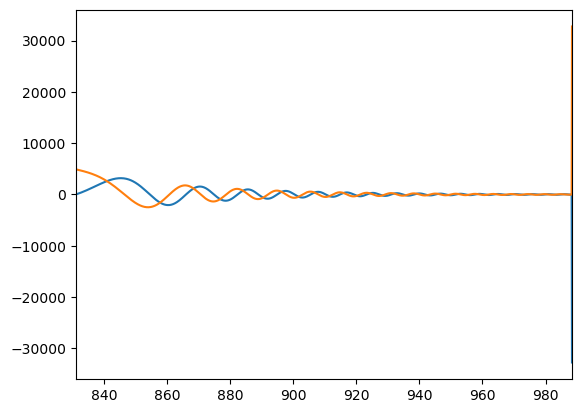

In [2]:
## Spiral

import numpy as np
from matplotlib import pyplot as plt
from kickercontrol.main import SignalGenerator
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')

X = SignalGenerator([KNY1938],
                oscillator_variables=[{"V0": ti,
                                       "V1": tf,
                                       "V2": 0,
                                       "V3": 0.15,
                                       "V4": 1/(tf-ti),
                                       "V5": 4.605 / (tf-ti),
                                       "V6":0.1}],
                                       oscillators=['custom'],
                                       expression="V2 + (V3 * np.exp(-V5 * (t - V0))) * np.sin(2 * np.pi * V4 * (1 + V6 * (t - V0)) * (t - V0))")


Y = SignalGenerator([KMX1938],
                oscillator_variables=[{"V0": ti,
                                       "V1": tf,
                                       "V2": 0,
                                       "V3": 0.15,
                                       "V4": 1/(tf-ti),
                                       "V5": 4.605 / (tf-ti),
                                       "V6":0.1}],
                                       oscillators=['custom'],
                                       expression="V2 + (V3 * np.exp(-V5 * (t - V0))) * np.sin(2 * np.pi * V4 * (1 + V6 * (t - V0)) * (t - V0)+np.pi/2)")
plt.show()
plt.plot(Y.dac_generators[0].generated_signal['time'],X.dac_generators[0].generated_signal)
plt.plot(Y.dac_generators[0].generated_signal['time'],Y.dac_generators[0].generated_signal)
plt.xlim(ti,tf)


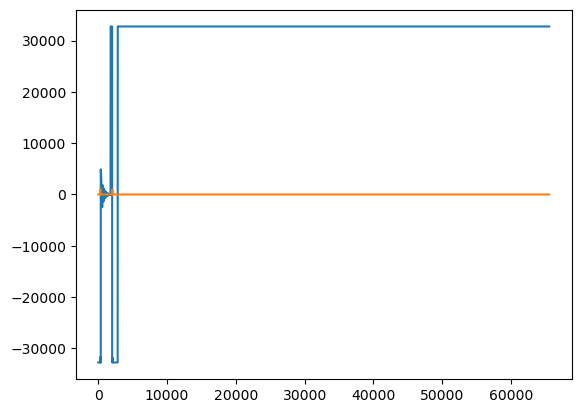

In [4]:
plt.plot(Y.dac_generators[0].generated_signal)
plt.plot(Y.dac_generators[0].kicker.read_dac()[:,1]-32767)